<a href="https://colab.research.google.com/github/jpfabri38558/P2FCE/blob/main/simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2ª AVALIÇÃO - FUNDAMENTOS COMPUTACIONAIS PARA ENGENHARIA

---

ALUNO: João Pedro Sobreira Fabri

MATRÍCULA: 2023100972


## Funções

### Importando o Repositório fo GitHub

In [84]:
!git clone https://github.com/jpfabri38558/P2FCE -qq

import sys
sys.path.append("/content/P2FCE")

fatal: destination path 'P2FCE' already exists and is not an empty directory.


### Importando as Funções

In [85]:
from P2FCE.functions import (
    parameters,
    arrhenius,
    simulation
)

In [81]:
print(parameters.__doc__)


  Classe que armazena os parâmetros do bioreator.

  Vmax_r : Velocidade máxima de referência (mg/L.h)
  T_r : Temperatura de referência (K)
  Km : Constante de Michaelis-Menten (mg/L)
  Ea : Energia de ativação (J/mol)
  R : Constante dos gases ideal (J/mol.K)
  


In [82]:
print(arrhenius.__doc__)


  Função que calcula a velocidade máxima em uma dada temperatura com base
  em uma referência conhecida dos parâmetros.

  T : Temperatura (K)
  prmtrs : Parâmetros do bioreator
  


In [83]:
print(simulation.__doc__)


  Função que simula o comportamento da concentração do substrato no tempo
  com base na equação diferêncial do modelo.

  t_i : Instante de tempo inicial (h)
  t_f : Instante de tempo final (h)
  S_0 : Concentração inicial do substrato (mg/L)
  T : Temperatura (K)
  prmtrs : Parâmetros do bioreator
  


## SIMULAÇÃO



### Simulação com Parâmetros Nominais para Diferentes Temperaturas




In [86]:
import numpy as np

# Instantes de tempo inicial e final
t_i, t_f = 0, 30

# Número de pontos da simulação
N = 100

# Lista de temperaturas
T = [298.15, 308.15, 318.15]

# Inicialização das matrizes resposta
t = np.zeros([len(T), N])
y = np.zeros([len(T), N])

# Preenchendo os resultados da simulação
for i in range(len(T)):
  t[i], y[i] = simulation(t_i, t_f, N, T[i])

### Determinação das Concentrações Finais

In [87]:
# Concentrações finais
for i in range(len(T)):
  print(f"Concentração final no bioreator para {T[i]} K : {y[i][-1]:.4f} mg/L")

Concentração final no bioreator para 298.15 K : 6.0735 mg/L
Concentração final no bioreator para 308.15 K : 0.2203 mg/L
Concentração final no bioreator para 318.15 K : 0.0016 mg/L


### Exibição Gráfica

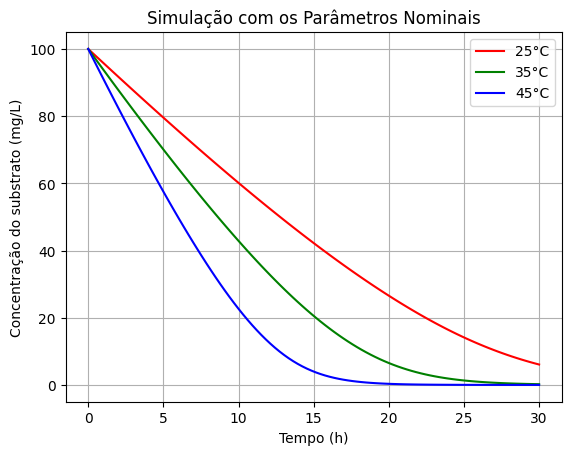

In [88]:
import matplotlib.pyplot as plt

plt.plot(t[0], y[0], "r-", label="25°C")
plt.plot(t[1], y[1], "g-", label="35°C")
plt.plot(t[2], y[2], "b-", label="45°C")
plt.xlabel('Tempo (h)')
plt.ylabel('Concentração do substrato (mg/L)')
plt.title('Simulação com os Parâmetros Nominais')
plt.legend()
plt.grid()
plt.show()

### Resultados e Discussão

As concentrações finais de substrato no bioreator após 30 horas simuladas foram:


- $S_f(25°C) = 6.0735 mg/L$

- $S_f(35°C) = 0.2203 mg/L$

- $S_f(45°C) = 0.0016 mg/L$


É possível observar que com o passar do tempo, a concentração de substrato no bioreator tende a 0 mg/L em todos os casos - sendo mais rápido em temperaturas elevadas.


Incrementos na temperatura causam um decaimento de concentração do substrato exponencialmente mais veloz, como previsto na equação de Arrhenius.


Temperaturas mais próximas à temperatura ambiente possuem uma curva de concentração com tendência mais linear. O decaimento exponencial se torna mais evidente em temperaturas elevadas.